# NIH EDA puntual

Objetivo:
- analizar frecuencia por patología,
- revisar el efecto de eliminar `No Finding`,
- medir cuántas etiquetas tiene cada imagen,
- estudiar co-ocurrencia entre patologías,
- dejar conclusiones útiles para interpretar por qué NIH sigue siendo difícil.

## Imports y rutas

In [1]:
from pathlib import Path
import ast
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
WORKING_DIR = DATA_DIR / "working"
MANIFESTS_DIR = DATA_DIR / "manifests"

DATASET_NAME = "nih"

manifest_full_path = MANIFESTS_DIR / "manifest_nih_final_with_paths.csv"
subset_large_path = WORKING_DIR / "nih" / "subsets" / "nih_subset_large_with_paths.csv"

print("manifest_full_path:", manifest_full_path)
print("subset_large_path:", subset_large_path)

manifest_full_path: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/manifest_nih_final_with_paths.csv
subset_large_path: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/nih/subsets/nih_subset_large_with_paths.csv


## Cargar datos

In [2]:
manifest_full = pd.read_csv(manifest_full_path)
subset_df = pd.read_csv(subset_large_path)

print("manifest_full:", manifest_full.shape)
print("subset_df:", subset_df.shape)

display(manifest_full.head(3))
display(subset_df.head(3))

manifest_full: (112120, 19)
subset_df: (19000, 19)


,image_name,finding_labels,Follow-up #,patient_id,patient_age,patient_gender,view_position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,dataset_name,modality,dimension,labels_list,split,split_final,file_path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,NIH_ChestXray14,xray,2D,['Cardiomegaly'],trainval,train,/mnt/d/Universidad/analitica/proyecto_analitic...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,NIH_ChestXray14,xray,2D,"['Cardiomegaly', 'Emphysema']",trainval,train,/mnt/d/Universidad/analitica/proyecto_analitic...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,NIH_ChestXray14,xray,2D,"['Cardiomegaly', 'Effusion']",trainval,train,/mnt/d/Universidad/analitica/proyecto_analitic...


,image_name,finding_labels,Follow-up #,patient_id,patient_age,patient_gender,view_position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,dataset_name,modality,dimension,labels_list,split,split_final,file_path
0,00022245_021.png,No Finding,21,22245,66,M,PA,2766,2716,0.143,0.143,NaN,NIH_ChestXray14,xray,2D,['No Finding'],trainval,train,/mnt/d/Universidad/analitica/proyecto_analitic...
1,00019544_000.png,No Finding,0,19544,44,M,PA,2978,2991,0.143,0.143,NaN,NIH_ChestXray14,xray,2D,['No Finding'],trainval,train,/mnt/d/Universidad/analitica/proyecto_analitic...
2,00009673_001.png,Pleural_Thickening,1,9673,46,F,PA,2992,2991,0.143,0.143,NaN,NIH_ChestXray14,xray,2D,['Pleural_Thickening'],trainval,train,/mnt/d/Universidad/analitica/proyecto_analitic...


## Parsear labels_list

In [3]:
def parse_labels(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        # fallback por si viene como string separado raro
        return [item.strip() for item in x.split("|") if item.strip()]
    return []

manifest_full["labels_list"] = manifest_full["labels_list"].apply(parse_labels)
subset_df["labels_list"] = subset_df["labels_list"].apply(parse_labels)

print("Ejemplos labels_list:")
display(manifest_full["labels_list"].head())
display(subset_df["labels_list"].head())

Ejemplos labels_list:


0               [Cardiomegaly]
1    [Cardiomegaly, Emphysema]
2     [Cardiomegaly, Effusion]
3                 [No Finding]
4                 [No Finding]
Name: labels_list, dtype: object

0            [No Finding]
1            [No Finding]
2    [Pleural_Thickening]
3            [No Finding]
4                [Nodule]
Name: labels_list, dtype: object

## Resumen básico

In [4]:
print("Columnas manifest_full:")
print(manifest_full.columns.tolist())

print("\nColumnas subset_df:")
print(subset_df.columns.tolist())

if "split_final" in subset_df.columns:
    print("\nConteo por split en subset_df:")
    display(subset_df["split_final"].value_counts().rename_axis("split_final").reset_index(name="count"))

Columnas manifest_full:
['image_name', 'finding_labels', 'Follow-up #', 'patient_id', 'patient_age', 'patient_gender', 'view_position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'dataset_name', 'modality', 'dimension', 'labels_list', 'split', 'split_final', 'file_path']

Columnas subset_df:
['image_name', 'finding_labels', 'Follow-up #', 'patient_id', 'patient_age', 'patient_gender', 'view_position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'dataset_name', 'modality', 'dimension', 'labels_list', 'split', 'split_final', 'file_path']

Conteo por split en subset_df:


,split_final,count
0,train,15000
1,val,2000
2,test,2000


## Frecuencia de etiquetas en el manifest completo

,label,count,ratio_over_images
0,No Finding,60361,0.538361
1,Infiltration,19894,0.177435
2,Effusion,13317,0.118775
3,Atelectasis,11559,0.103095
4,Nodule,6331,0.056466
5,Mass,5782,0.051570
6,Pneumothorax,5302,0.047289
7,Consolidation,4667,0.041625
8,Pleural_Thickening,3385,0.030191
9,Cardiomegaly,2776,0.024759


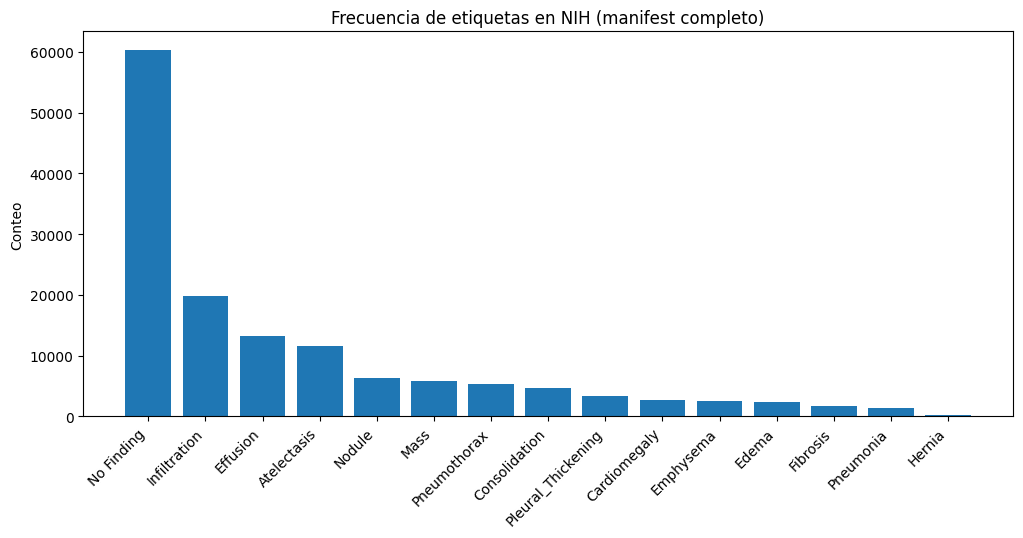

In [5]:
full_label_counter = Counter()
for labels in manifest_full["labels_list"]:
    full_label_counter.update(labels)

full_label_counts = pd.DataFrame(
    sorted(full_label_counter.items(), key=lambda x: (-x[1], x[0])),
    columns=["label", "count"]
)
full_label_counts["ratio_over_images"] = full_label_counts["count"] / len(manifest_full)

display(full_label_counts)

plt.figure(figsize=(12, 5))
plt.bar(full_label_counts["label"], full_label_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Frecuencia de etiquetas en NIH (manifest completo)")
plt.ylabel("Conteo")
plt.show()

In [6]:
n_no_finding = sum("No Finding" in labels for labels in manifest_full["labels_list"])
ratio_no_finding = n_no_finding / len(manifest_full)

print("Imágenes con 'No Finding':", n_no_finding)
print("Proporción con 'No Finding':", round(ratio_no_finding, 4))

Imágenes con 'No Finding': 60361
Proporción con 'No Finding': 0.5384


In [7]:
IGNORE_LABELS = {"No Finding"}

manifest_wo_nf = manifest_full.copy()
manifest_wo_nf["labels_wo_nf"] = manifest_wo_nf["labels_list"].apply(
    lambda labels: [lab for lab in labels if lab not in IGNORE_LABELS]
)

subset_wo_nf = subset_df.copy()
subset_wo_nf["labels_wo_nf"] = subset_wo_nf["labels_list"].apply(
    lambda labels: [lab for lab in labels if lab not in IGNORE_LABELS]
)

manifest_wo_nf_nonempty = manifest_wo_nf[manifest_wo_nf["labels_wo_nf"].apply(len) > 0].copy()
subset_wo_nf_nonempty = subset_wo_nf[subset_wo_nf["labels_wo_nf"].apply(len) > 0].copy()

print("manifest_full original:", manifest_full.shape)
print("manifest sin No Finding y no vacío:", manifest_wo_nf_nonempty.shape)

print("subset_df original:", subset_df.shape)
print("subset sin No Finding y no vacío:", subset_wo_nf_nonempty.shape)

manifest_full original: (112120, 19)
manifest sin No Finding y no vacío: (51759, 20)
subset_df original: (19000, 19)
subset sin No Finding y no vacío: (8345, 20)


,label,count,ratio_over_images
0,Infiltration,19894,0.384358
1,Effusion,13317,0.257289
2,Atelectasis,11559,0.223323
3,Nodule,6331,0.122317
4,Mass,5782,0.111710
5,Pneumothorax,5302,0.102436
6,Consolidation,4667,0.090168
7,Pleural_Thickening,3385,0.065399
8,Cardiomegaly,2776,0.053633
9,Emphysema,2516,0.048610


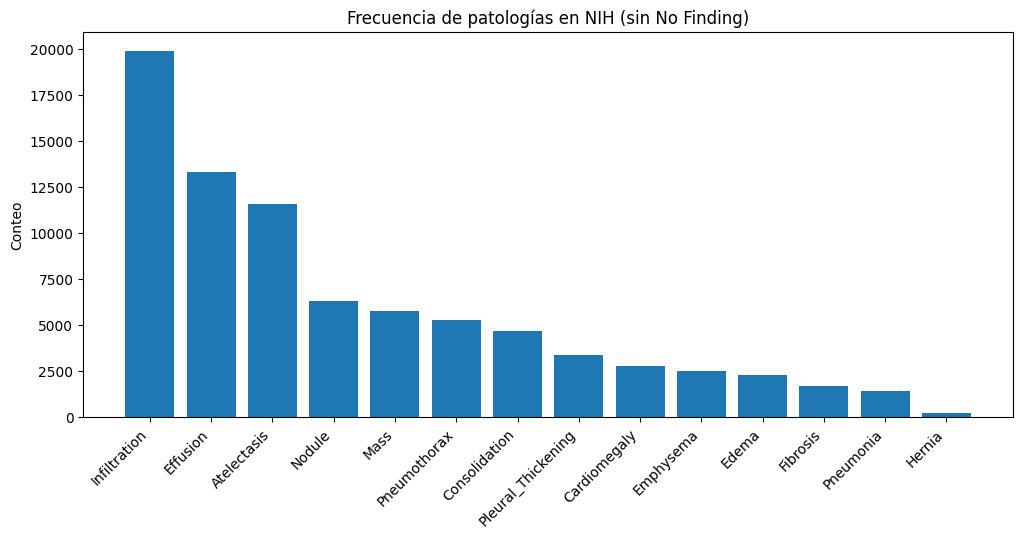

In [8]:
filtered_label_counter = Counter()
for labels in manifest_wo_nf_nonempty["labels_wo_nf"]:
    filtered_label_counter.update(labels)

filtered_label_counts = pd.DataFrame(
    sorted(filtered_label_counter.items(), key=lambda x: (-x[1], x[0])),
    columns=["label", "count"]
)
filtered_label_counts["ratio_over_images"] = filtered_label_counts["count"] / len(manifest_wo_nf_nonempty)

display(filtered_label_counts)

plt.figure(figsize=(12, 5))
plt.bar(filtered_label_counts["label"], filtered_label_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Frecuencia de patologías en NIH (sin No Finding)")
plt.ylabel("Conteo")
plt.show()

In [9]:
manifest_full["n_labels_raw"] = manifest_full["labels_list"].apply(len)
manifest_wo_nf_nonempty["n_labels_wo_nf"] = manifest_wo_nf_nonempty["labels_wo_nf"].apply(len)

print("Distribución de número de etiquetas por imagen (raw):")
display(
    manifest_full["n_labels_raw"]
    .value_counts()
    .sort_index()
    .rename_axis("n_labels")
    .reset_index(name="count")
)

print("\nDistribución de número de etiquetas por imagen (sin No Finding):")
display(
    manifest_wo_nf_nonempty["n_labels_wo_nf"]
    .value_counts()
    .sort_index()
    .rename_axis("n_labels")
    .reset_index(name="count")
)

Distribución de número de etiquetas por imagen (raw):


,n_labels,count
0,1,91324
1,2,14306
2,3,4856
3,4,1247
4,5,301
5,6,67
6,7,16
7,8,1
8,9,2



Distribución de número de etiquetas por imagen (sin No Finding):


,n_labels,count
0,1,30963
1,2,14306
2,3,4856
3,4,1247
4,5,301
5,6,67
6,7,16
7,8,1
8,9,2


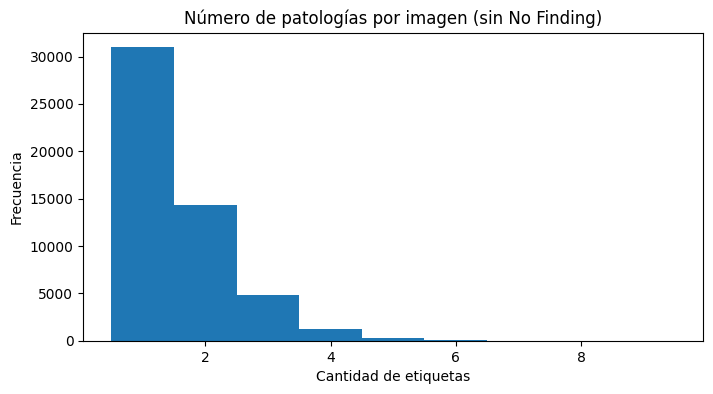

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(manifest_wo_nf_nonempty["n_labels_wo_nf"], bins=np.arange(1, manifest_wo_nf_nonempty["n_labels_wo_nf"].max() + 2) - 0.5)
plt.title("Número de patologías por imagen (sin No Finding)")
plt.xlabel("Cantidad de etiquetas")
plt.ylabel("Frecuencia")
plt.show()

,label,count,ratio_over_images
0,Infiltration,3151,0.377591
1,Effusion,2095,0.251049
2,Atelectasis,1894,0.226962
3,Nodule,1043,0.124985
4,Mass,918,0.110006
5,Pneumothorax,759,0.090953
6,Consolidation,692,0.082924
7,Pleural_Thickening,513,0.061474
8,Cardiomegaly,444,0.053206
9,Emphysema,352,0.042181


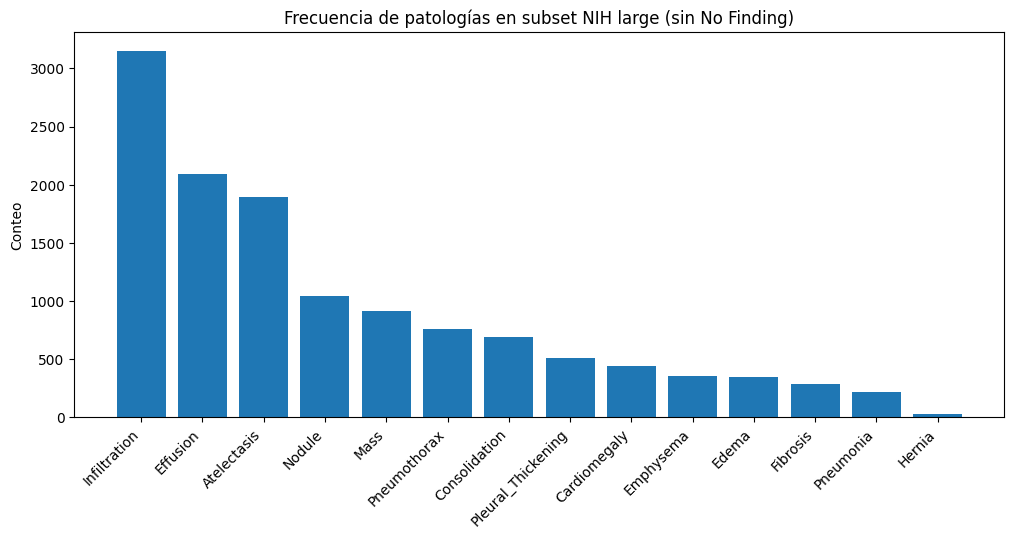

In [11]:
subset_label_counter = Counter()
for labels in subset_wo_nf_nonempty["labels_wo_nf"]:
    subset_label_counter.update(labels)

subset_label_counts = pd.DataFrame(
    sorted(subset_label_counter.items(), key=lambda x: (-x[1], x[0])),
    columns=["label", "count"]
)
subset_label_counts["ratio_over_images"] = subset_label_counts["count"] / len(subset_wo_nf_nonempty)

display(subset_label_counts)

plt.figure(figsize=(12, 5))
plt.bar(subset_label_counts["label"], subset_label_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Frecuencia de patologías en subset NIH large (sin No Finding)")
plt.ylabel("Conteo")
plt.show()

In [12]:
rows = []
for _, row in subset_wo_nf_nonempty.iterrows():
    for label in row["labels_wo_nf"]:
        rows.append({
            "split_final": row["split_final"],
            "label": label
        })

subset_long = pd.DataFrame(rows)

split_label_counts = (
    subset_long.groupby(["split_final", "label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split_final", "label"])
)

display(split_label_counts)

pivot_split_label = split_label_counts.pivot(index="label", columns="split_final", values="count").fillna(0).astype(int)
display(pivot_split_label)

,split_final,label,count
0,test,Atelectasis,258
1,test,Cardiomegaly,93
2,test,Consolidation,148
3,test,Edema,66
4,test,Effusion,386
5,test,Emphysema,88
6,test,Fibrosis,42
7,test,Hernia,2
8,test,Infiltration,459
9,test,Mass,150


split_final,test,train,val
label,,,
Atelectasis,258,1423,213
Cardiomegaly,93,311,40
Consolidation,148,488,56
Edema,66,240,39
Effusion,386,1493,216
Emphysema,88,223,41
Fibrosis,42,211,31
Hernia,2,22,3
Infiltration,459,2354,338


In [13]:
labels_sorted = sorted(filtered_label_counts["label"].tolist())
label_to_idx = {label: i for i, label in enumerate(labels_sorted)}

cooc = np.zeros((len(labels_sorted), len(labels_sorted)), dtype=np.int32)

for labels in manifest_wo_nf_nonempty["labels_wo_nf"]:
    unique_labels = sorted(set(labels))
    for a in unique_labels:
        for b in unique_labels:
            cooc[label_to_idx[a], label_to_idx[b]] += 1

cooc_df = pd.DataFrame(cooc, index=labels_sorted, columns=labels_sorted)
display(cooc_df)

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
Atelectasis,11559,370,1223,221,3275,424,220,40,3264,739,590,496,262,774
Cardiomegaly,370,2776,169,127,1063,44,52,7,587,102,108,111,41,49
Consolidation,1223,169,4667,162,1287,103,79,4,1221,610,428,251,123,223
Edema,221,127,162,2303,593,30,9,3,981,129,131,64,340,33
Effusion,3275,1063,1287,593,13317,359,188,21,4000,1254,912,849,269,996
Emphysema,424,44,103,30,359,2516,36,4,449,215,115,151,23,747
Fibrosis,220,52,79,9,188,36,1686,8,345,117,166,176,11,80
Hernia,40,7,4,3,21,4,8,227,33,25,10,8,3,9
Infiltration,3264,587,1221,981,4000,449,345,33,19894,1159,1546,750,605,946
Mass,739,102,610,129,1254,215,117,25,1159,5782,906,452,71,431


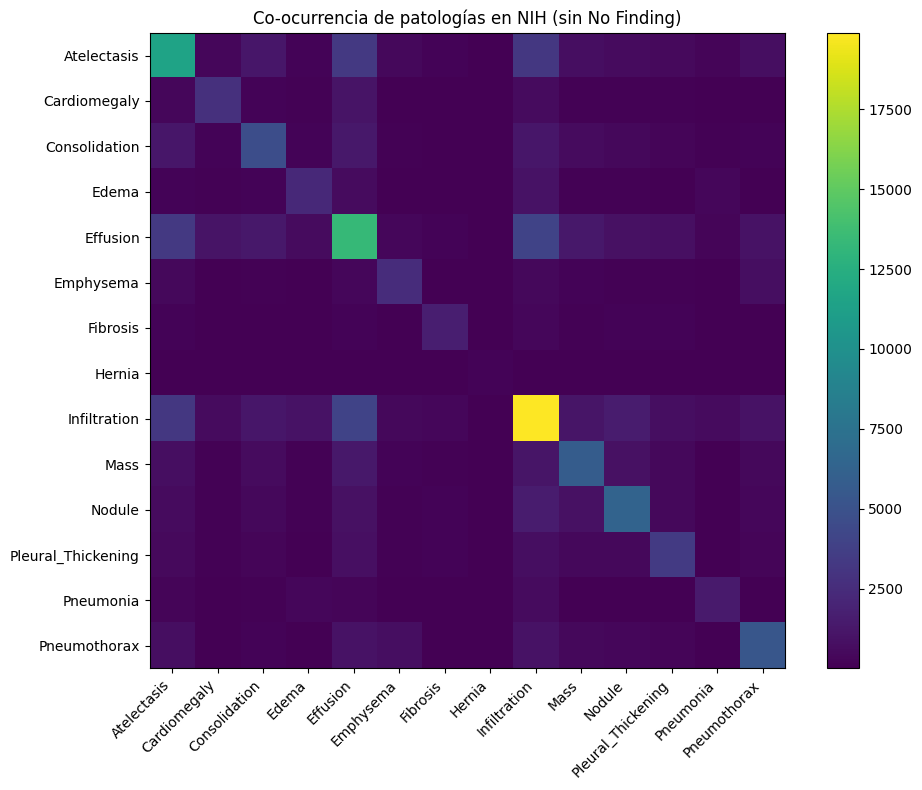

In [14]:
plt.figure(figsize=(10, 8))
plt.imshow(cooc_df.values)
plt.xticks(np.arange(len(labels_sorted)), labels_sorted, rotation=45, ha="right")
plt.yticks(np.arange(len(labels_sorted)), labels_sorted)
plt.title("Co-ocurrencia de patologías en NIH (sin No Finding)")
plt.colorbar()
plt.tight_layout()
plt.show()

In [15]:
pair_rows = []
for i in range(len(labels_sorted)):
    for j in range(i + 1, len(labels_sorted)):
        pair_rows.append({
            "label_a": labels_sorted[i],
            "label_b": labels_sorted[j],
            "count": int(cooc[i, j])
        })

top_pairs_df = pd.DataFrame(pair_rows).sort_values("count", ascending=False).reset_index(drop=True)
display(top_pairs_df.head(20))

,label_a,label_b,count
0,Effusion,Infiltration,4000
1,Atelectasis,Effusion,3275
2,Atelectasis,Infiltration,3264
3,Infiltration,Nodule,1546
4,Consolidation,Effusion,1287
5,Effusion,Mass,1254
6,Atelectasis,Consolidation,1223
7,Consolidation,Infiltration,1221
8,Infiltration,Mass,1159
9,Cardiomegaly,Effusion,1063


,label,count,ratio_over_images
0,Hernia,27,0.003235
1,Pneumonia,215,0.025764
2,Fibrosis,284,0.034032
3,Edema,345,0.041342
4,Emphysema,352,0.042181
5,Cardiomegaly,444,0.053206
6,Pleural_Thickening,513,0.061474
7,Consolidation,692,0.082924
8,Pneumothorax,759,0.090953
9,Mass,918,0.110006


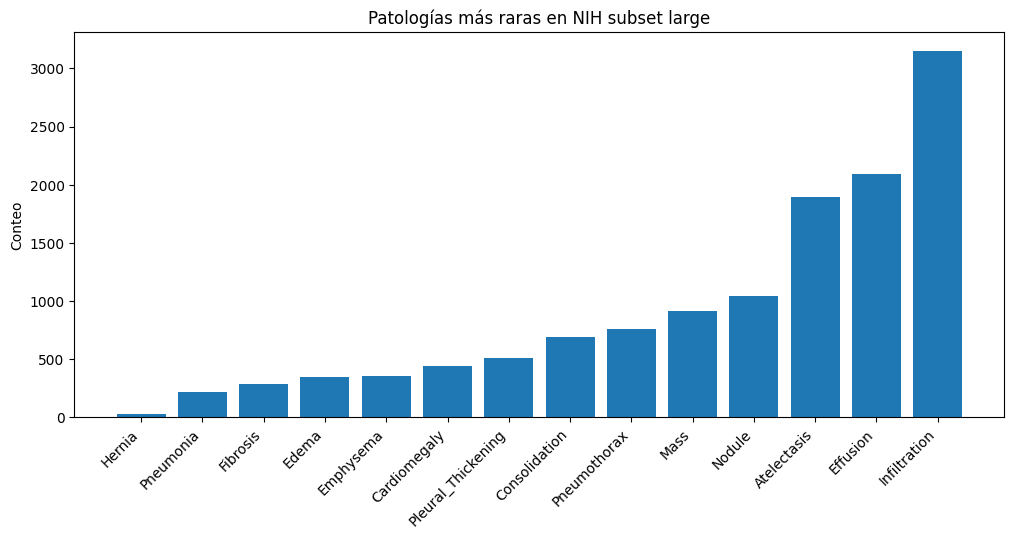

In [16]:
subset_label_counts_sorted = subset_label_counts.sort_values("count", ascending=True).reset_index(drop=True)
display(subset_label_counts_sorted)

plt.figure(figsize=(12, 5))
plt.bar(subset_label_counts_sorted["label"], subset_label_counts_sorted["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Patologías más raras en NIH subset large")
plt.ylabel("Conteo")
plt.show()

In [17]:
summary = {
    "manifest_full_rows": int(len(manifest_full)),
    "manifest_rows_without_no_finding_nonempty": int(len(manifest_wo_nf_nonempty)),
    "subset_large_rows": int(len(subset_df)),
    "subset_large_rows_without_no_finding_nonempty": int(len(subset_wo_nf_nonempty)),
    "n_images_with_no_finding": int(n_no_finding),
    "ratio_no_finding": float(ratio_no_finding),
    "n_unique_pathologies_without_no_finding": int(len(labels_sorted)),
    "pathology_counts_subset_large": dict(subset_label_counts[["label", "count"]].values),
    "labels_per_image_distribution": dict(
        manifest_wo_nf_nonempty["n_labels_wo_nf"].value_counts().sort_index()
    ),
}

summary

{'manifest_full_rows': 112120,
 'manifest_rows_without_no_finding_nonempty': 51759,
 'subset_large_rows': 19000,
 'subset_large_rows_without_no_finding_nonempty': 8345,
 'n_images_with_no_finding': 60361,
 'ratio_no_finding': 0.5383606849803781,
 'n_unique_pathologies_without_no_finding': 14,
 'pathology_counts_subset_large': {'Infiltration': 3151,
  'Effusion': 2095,
  'Atelectasis': 1894,
  'Nodule': 1043,
  'Mass': 918,
  'Pneumothorax': 759,
  'Consolidation': 692,
  'Pleural_Thickening': 513,
  'Cardiomegaly': 444,
  'Emphysema': 352,
  'Edema': 345,
  'Fibrosis': 284,
  'Pneumonia': 215,
  'Hernia': 27},
 'labels_per_image_distribution': {1: np.int64(30963),
  2: np.int64(14306),
  3: np.int64(4856),
  4: np.int64(1247),
  5: np.int64(301),
  6: np.int64(67),
  7: np.int64(16),
  8: np.int64(1),
  9: np.int64(2)}}

In [18]:
EDA_DIR = WORKING_DIR / "nih" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

full_label_counts.to_csv(EDA_DIR / "nih_full_label_counts.csv", index=False)
filtered_label_counts.to_csv(EDA_DIR / "nih_filtered_label_counts.csv", index=False)
subset_label_counts.to_csv(EDA_DIR / "nih_subset_large_label_counts.csv", index=False)
split_label_counts.to_csv(EDA_DIR / "nih_split_label_counts.csv", index=False)
cooc_df.to_csv(EDA_DIR / "nih_cooccurrence_matrix.csv", index=True)
top_pairs_df.to_csv(EDA_DIR / "nih_top_pairs.csv", index=False)

with open(EDA_DIR / "nih_eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("EDA guardado en:", EDA_DIR)

TypeError: Object of type int64 is not JSON serializable